In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, *path.parents):
        if (candidate / "scripts" / "uci_pipeline.py").exists():
            return candidate
    return path


PROJECT_ROOT = find_project_root()
DATA = PROJECT_ROOT / "data" / "modeling"
AUDIT = DATA / "audit"
AUDIT.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from customer_base_audit import (
    load_fact_transactions,
    hist_plot,
    profit_decile_table,
)
from sim_profit import simulate_line_profit

print("Setup complete · audit dir:", AUDIT)

Setup complete · audit dir: C:\Users\ahmed\Desktop\Projects\CLV\data\modeling\audit


## Rwa Transaction Data

In [3]:
transaction_data_raw = load_fact_transactions(DATA / "uci_fact_transactions.parquet")

# transaction_data_raw stays revenue-only. simulate_line_profit() layers a
# deterministic, reproducible sim_profit (COGS/payment/fulfillment/shipping)
# on top — see scripts/sim_profit.py for the assumptions.
transaction_data = simulate_line_profit(transaction_data_raw, revenue_col='line_total')

transaction_data['year'] = transaction_data['order_date'].dt.year
transaction_data['cohort'] = transaction_data['order_date'].dt.to_period('Q').astype(str)
transaction_data.rename(columns={'line_total': 'spend'}, inplace=True)

transaction_data = transaction_data[
    ['customer_id', 'order_id', 'order_date', 'year', 'cohort', 'product_id',
     'quantity', 'unit_price', 'country', 'spend', 'sim_profit']
]

print(f"The rawtransaction level table: {len(transaction_data):,} rows")
print(f'The start date is {transaction_data["order_date"].min()}\nThe end date is {transaction_data["order_date"].max()}')
transaction_data.head()



The rawtransaction level table: 798,626 rows
The start date is 2009-12-01 07:45:00
The end date is 2011-12-09 12:50:00


,customer_id,order_id,order_date,year,cohort,product_id,quantity,unit_price,country,spend,sim_profit
0,13085,489434,2009-12-01 07:45:00,2009,2009Q4,85048,12,6.95,United Kingdom,83.4,43.952604
1,13085,489434,2009-12-01 07:45:00,2009,2009Q4,79323P,12,6.75,United Kingdom,81.0,37.356657
2,13085,489434,2009-12-01 07:45:00,2009,2009Q4,79323W,12,6.75,United Kingdom,81.0,27.950127
3,13085,489434,2009-12-01 07:45:00,2009,2009Q4,22041,48,2.10,United Kingdom,100.8,41.710847
4,13085,489434,2009-12-01 07:45:00,2009,2009Q4,21232,24,1.25,United Kingdom,30.0,10.798143


## `sim_profit` formula

UCI Online Retail II has no cost data, so `sim_profit` is a **simulation**, not
real profit — built deterministically (MD5 hash of `product_id` / `order_id`,
no randomness/seed) by `scripts/sim_profit.py::simulate_line_profit()`:

```
sim_profit = revenue − sim_cogs − sim_payment_fee − sim_fulfillment_cost − sim_shipping_cost
```

| Component | Formula |
|---|---|
| `sim_cogs` | `revenue × COGS_rate`, `COGS_rate ∈ [30%, 60%]` — deterministic hash of `product_id` |
| `sim_payment_fee` | `(order_revenue × 2.9% + $0.30)` per order, allocated to lines by revenue share |
| `sim_fulfillment_cost` | `($1.50 + $0.20 × order_qty) × (1.5 if non-UK else 1)` per order, allocated by quantity share |
| `sim_shipping_cost` | `tier_base + tier_per_item × order_qty` per order — domestic (UK) / near (EIRE, Netherlands, Belgium) / far (rest of the EU set) — allocated by quantity share |

No returns/cancellations term (not modeled — see the module docstring for why). Rates/constants live at the top of `scripts/sim_profit.py`.

## Transaction-Level Summary Data (Order Level)

In [4]:
order_data = transaction_data.groupby(['customer_id', 'order_id', 'year']).agg({'spend': 'sum'}).reset_index()


print(f"The transaction level table: {len(order_data):,} rows")
order_data.head()

The transaction level table: 36,684 rows


,customer_id,order_id,year,spend
0,12346,491725,2009,45.0
1,12346,491742,2009,22.5
2,12346,491744,2009,22.5
3,12346,492718,2009,22.5
4,12346,492722,2009,1.0


## Customer-Level Summary

In [5]:
customer_data = (
    transaction_data
    .groupby(['customer_id', 'year', 'cohort'])
    .agg(
        Total_spend=('spend', 'sum'),
        Num_trans=('order_id', 'nunique'),
        Total_profit=('sim_profit', 'sum'),
    )
    .reset_index()
)

customer_data['Avg_trans_spend'] = customer_data['Total_spend'] / customer_data['Num_trans']
customer_data['Profit_margin'] = customer_data['Total_profit'] / customer_data['Total_spend']


print(f"The customer level table: {len(customer_data):,} rows")
customer_data.head()

The customer level table: 17,844 rows


,customer_id,year,cohort,Total_spend,Num_trans,Total_profit,Avg_trans_spend,Profit_margin
0,12346,2009,2009Q4,113.50,5,41.345195,22.70,0.364275
1,12346,2010,2010Q1,117.05,5,43.006218,23.41,0.367417
2,12346,2010,2010Q2,142.31,1,68.044911,142.31,0.478146
3,12346,2011,2011Q1,77183.60,1,3898.177888,77183.60,0.050505
4,12348,2010,2010Q3,222.16,1,-134.926743,222.16,-0.607340


## 01- How Different Are Your Customer?

In [6]:
customer_2010 = customer_data[customer_data['year'] == 2010]

print(f"The customers in 2010 is: {len(customer_data):,}")
print(f'The min spend is {customer_2010["Total_spend"].min():,.2f} \nThe max spend is {customer_2010["Total_spend"].max():,.2f}')
customer_2010.head(3)

The customers in 2010 is: 17,844
The min spend is 1.30 
The max spend is 107,957.29


,customer_id,year,cohort,Total_spend,Num_trans,Total_profit,Avg_trans_spend,Profit_margin
1,12346,2010,2010Q1,117.05,5,43.006218,23.41,0.367417
2,12346,2010,2010Q2,142.31,1,68.044911,142.31,0.478146
4,12348,2010,2010Q3,222.16,1,-134.926743,222.16,-0.607340


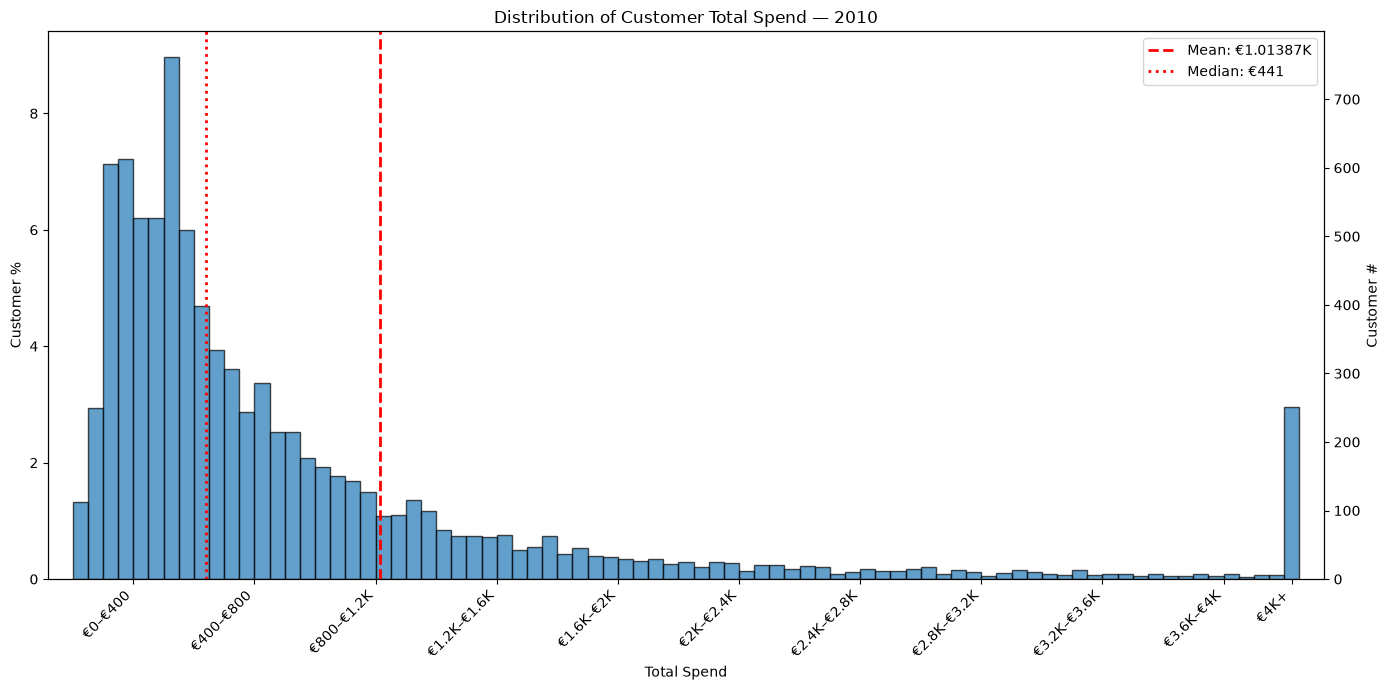

,Metric,Value
0,Customers,"8,492"
1,Total revenue,€8609.77K
2,Median spend per customer,€441
3,Average spend per customer,€1.01387K
4,Min customer spend,€1
5,Max customer spend,€107.957K
6,Customers spending < €50,113 (1.3%)
7,Customers spending >= €4K,251 (3.0%)
8,Customers spending less than the mean,"6,693 (78.8%)"


In [7]:
hist_plot(
    customer_2010,
    threshold=4000,
    bin_width=50,
    x_col='Total_spend',
    title='Distribution of Customer Total Spend \u2014 2010',
    currency='Euro',
    print_table=True,
)

### Decomposing Total Spend

$$
\text{total spend} = \#\text{transactions} \times \frac{\text{total spend}}{\#\text{transactions}}
$$

$$
= \#\text{transactions} \times \text{average spend per transaction}
$$


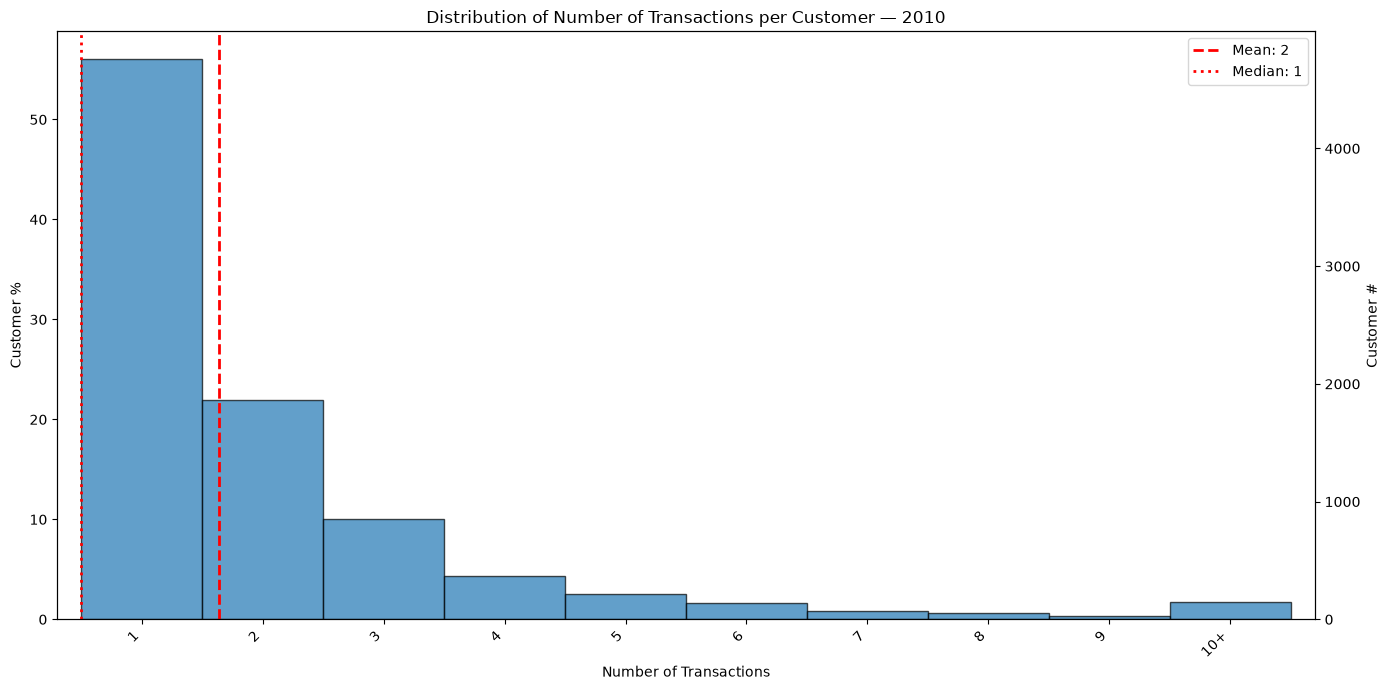

In [8]:
hist_plot(
    customer_2010,
    threshold=10,
    bin_width=1,
    x_col='Num_trans',
    xlabel='Number of Transactions',
    title='Distribution of Number of Transactions per Customer \u2014 2010',
    value_kind='number',
)



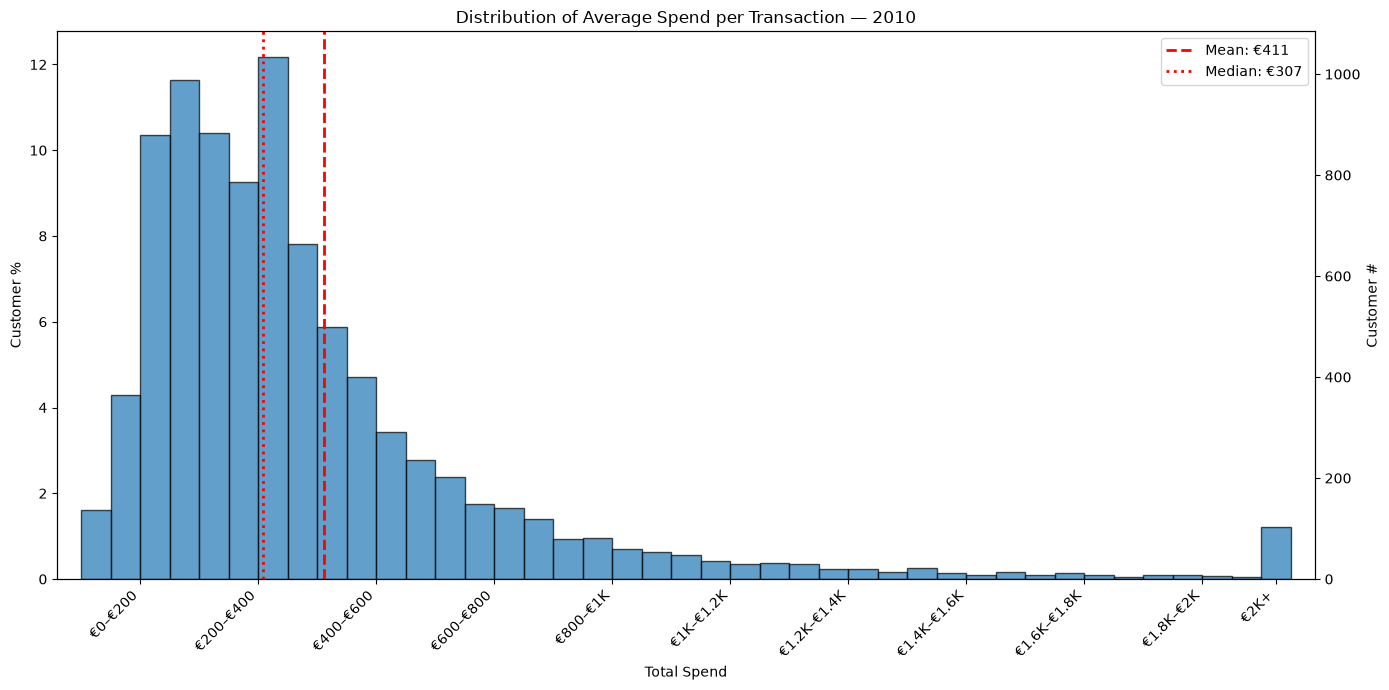

In [9]:
hist_plot(
    customer_2010,
    threshold=2000,
    bin_width=50,
    x_col='Avg_trans_spend',
    title='Distribution of Average Spend per Transaction \u2014 2010',
    currency='Euro',
)

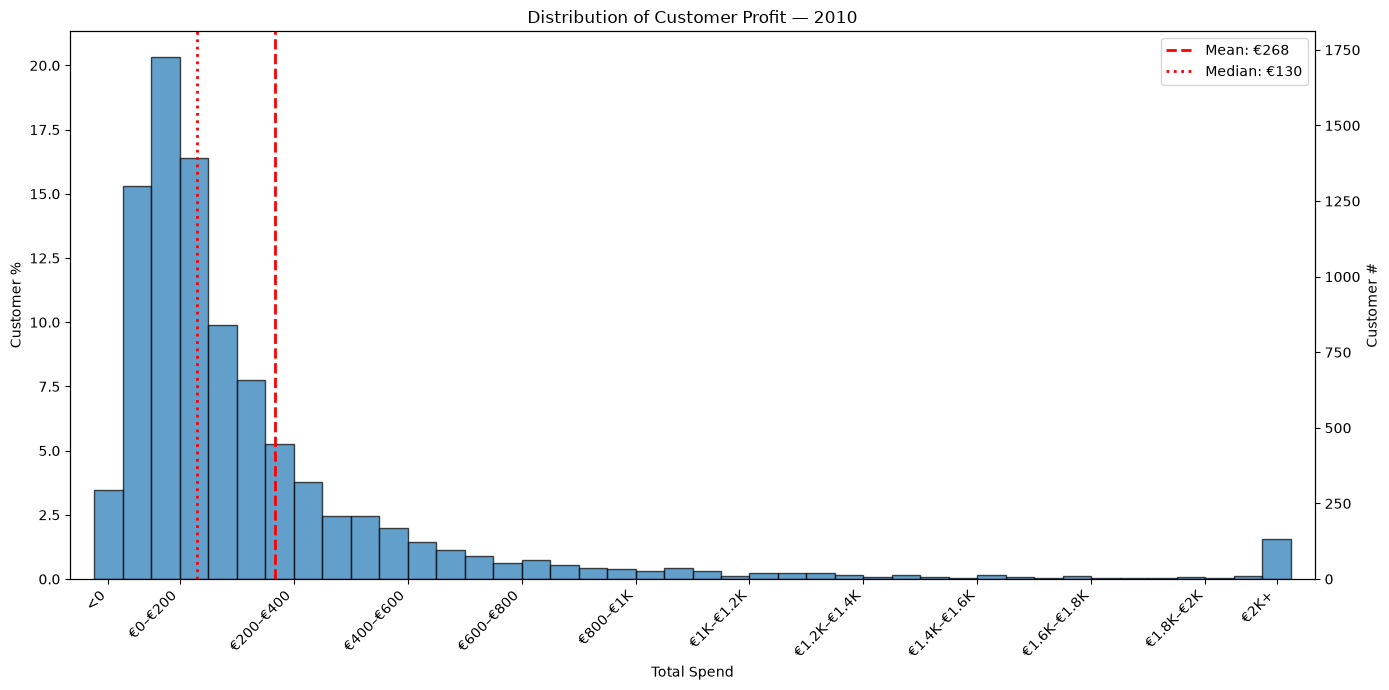

In [10]:
hist_plot(
    customer_2010,
    threshold=2000,
    bin_width=50,
    x_col='Total_profit',
    title='Distribution of Customer Profit \u2014 2010',
    currency='Euro',
    negative_bin=True,
)

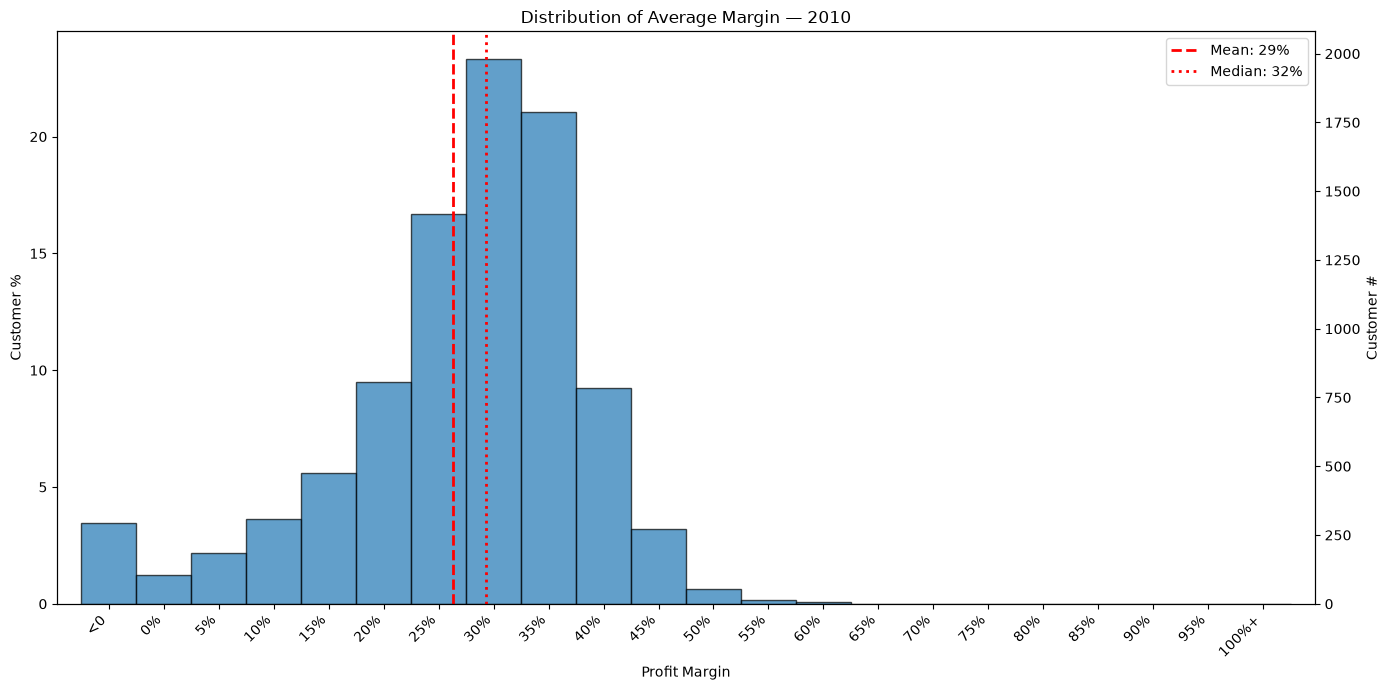

In [11]:
hist_plot(
    customer_2010,
    threshold=1,
    bin_width=0.05,
    x_col='Profit_margin',
    xlabel='Profit Margin',
    title='Distribution of Average Margin \u2014 2010',
    value_kind='percent',
    negative_bin=True,
)

### Decomposing Profit

As a first step, we decompose the total profit associated with each decile (or the customer base overall) as follows:

$$
\text{profit} = \#\text{customers} \times \frac{\text{profit}}{\#\text{customers}}
$$

$$
= \#\text{customers} \times \text{average profit per customer}
$$

Next, to get a sense of what lies behind any observed differences in **average profit per customer**, we use the following multiplicative decomposition:

$$
\text{average profit per customer} = \frac{\text{profit}}{\#\text{customers}} = \frac{\text{revenue}}{\#\text{customers}} \times \frac{\text{profit}}{\text{revenue}}
$$

$$
= \text{average spend per customer} \times \text{average margin}
$$

Finally, to get a sense of what lies behind any observed differences in **average spend per customer**, we decompose it in the following manner:

$$
\text{average spend per customer} = \frac{\text{revenue}}{\#\text{customers}} = \frac{\#\text{transactions}}{\#\text{customers}} \times \frac{\text{revenue}}{\#\text{transactions}}
$$

$$
= \text{average order frequency (AOF)} \times \text{average order value (AOV)}
$$

Note that $\text{AOF} \times \text{AOV} \times \text{average margin} = \text{average profit per customer}$.

###  — Decomposition of Customer-Decile Profit

Customers are ranked by profit (descending) and split into 10 **equal-sized**
groups (~10% of customers each). For each decile we report its share of
total profit, average spend/profit per customer, AOF (transactions per
customer), AOV (revenue per transaction), and average margin — showing how
those drivers differ between the most and least profitable customer
segments.

In [12]:
profit_decile_table(customer_2010, by='customers', currency='Euro')

,Decile,% Customers,% Profit,Avg spend per cust,Avg profit per cust,AOF,AOV,Avg Margin
0,1,10%,61%,"€5,186","€1,620",6.4,€809,31%
1,2,10%,15%,"€1,315",€411,2.9,€448,31%
2,3,10%,10%,€867,€269,2.3,€383,31%
3,4,10%,7%,€675,€198,1.9,€364,29%
4,5,10%,6%,€485,€149,1.6,€308,31%
5,6,10%,4%,€395,€116,1.4,€283,29%
6,7,10%,3%,€328,€90,1.3,€248,27%
7,8,10%,2%,€255,€64,1.2,€213,25%
8,9,10%,2%,€191,€41,1.2,€164,22%
9,10,10%,-11%,€437,€-283,1.3,€337,-65%


###  — Summary of Profit Deciles

Customers are again ranked by profit (descending), but this time grouped
into 10 **equal-profit** slices (~10% of total profit each), from the most
to the least profitable. The `% Customers` column shows how few (or many)
customers it takes to generate each successive 10% of profit — e.g. a small
top slice of customers usually accounts for the first 10%, while a much
larger slice of low-value customers is needed to make up the last 10%.

In [13]:
profit_decile_table(customer_2010, by='profit', currency='Euro')

,Decile,% Customers,% Profit,Avg spend per cust,Avg profit per cust,AOF,AOV,Avg Margin
0,1,0.1%,10%,"€64,561","€22,403",24.8,"€2,603",35%
1,2,0.4%,10%,"€29,528","€7,508",19.5,"€1,517",25%
2,3,1%,10%,"€10,186","€3,314",13.5,€752,33%
3,4,2%,10%,"€5,323","€1,669",7.7,€691,31%
4,5,3%,10%,"€2,969",€992,5.1,€577,33%
5,6,4%,10%,"€2,061",€653,3.8,€540,32%
6,7,6%,10%,"€1,465",€462,3.3,€449,32%
7,8,8%,10%,"€1,047",€329,2.6,€410,31%
8,9,11%,10%,€773,€234,2.0,€382,30%
9,10,65%,10%,€372,€41,1.4,€272,11%
